In [1]:
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import snowflake.connector
from dotenv import load_dotenv
import os
import re

load_dotenv()
print("Libraries are loaded")

Libraries are loaded


In [2]:
conn = snowflake.connector.connect(
    user="ATHULYA2303",
    password=os.getenv("SNOWFLAKE_PASSWORD"),
    account="gsc07824.us-east-1",
    warehouse="COMPUTE_WH",
    database="MOVIE_ANALYTICS",
    schema="RAW"
)

df = pd.read_sql("SELECT * FROM raw.reddit_comments", conn)
conn.close()

print(f"Loaded {len(df)} comments from Snowflake")
df.head()

/var/folders/9v/m7xlhp3j2cz1nmdxztqqdw200000gn/T/ipykernel_9682/3332840618.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM raw.reddit_comments", conn)


Loaded 1339 comments from Snowflake


,MOVIE_NAME,SUBREDDIT,COMMENT_TEXT,UPVOTES,COMMENT_TIMESTAMP,EXTRACTED_RATING
0,Charlie and the Chocolate Factory (2005) - Par...,movies,"As far as the Oompa-Loompa songs for 2005 go, ...",1,2026-03-04 19:24:07,None
1,Netflix’s ‘The 99’ers’ Adds Six To Cast,movies,This would be like making a story about a 1972...,1,2026-03-04 18:48:04,None
2,Netflix’s ‘The 99’ers’ Adds Six To Cast,movies,&gt; Netflix‘s drama The 99’ers has added six...,1,2026-03-04 18:34:18,None
3,Netflix’s ‘The 99’ers’ Adds Six To Cast,movies,93 to go.\n,1,2026-03-04 18:58:58,None
4,Netflix’s ‘The 99’ers’ Adds Six To Cast,movies,I liked Wilson in her small role in Dial of De...,1,2026-03-04 19:31:53,None


In [3]:
#sentiment analysis
sia = SentimentIntensityAnalyzer()

def analyze_comment(text):
    text = str(text)
    
    # VADER sentiment
    scores = sia.polarity_scores(text)
    compound = scores["compound"]  # -1 to +1
    
    # Sentiment label
    if compound >= 0.05:
        sentiment = "positive"
    elif compound <= -0.05:
        sentiment = "negative"
    else:
        sentiment = "neutral"
    
    # Score 1-10
    score_10 = round((compound + 1) * 4.5 + 1, 2)  # maps to 1–10
    
    return sentiment, score_10, compound

# Apply to all comments
df[["SENTIMENT", "SCORE_10", "COMPOUND"]] = df["COMMENT_TEXT"].apply(
    lambda x: pd.Series(analyze_comment(x))
)

print("Sentiment analysis complete!")
print(df["SENTIMENT"].value_counts())
df[["COMMENT_TEXT", "SENTIMENT", "SCORE_10"]].head(10)

Sentiment analysis complete!
SENTIMENT
positive    632
neutral     447
negative    260
Name: count, dtype: int64


,COMMENT_TEXT,SENTIMENT,SCORE_10
0,"As far as the Oompa-Loompa songs for 2005 go, ...",negative,2.48
1,This would be like making a story about a 1972...,positive,7.13
2,&gt; Netflix‘s drama The 99’ers has added six...,positive,9.55
3,93 to go.\n,neutral,5.50
4,I liked Wilson in her small role in Dial of De...,positive,9.15
5,People that wear a mask but awkwardly let it h...,negative,1.60
6,Imagine having a video circulated online talki...,negative,2.99
7,"Megadoc is a truly breathtaking watch, availab...",positive,9.79
8,Why is he eating his mask...,neutral,5.50
9,Its truly an accomplishment to have a producti...,negative,3.06


In [6]:
#pip install matplotlib

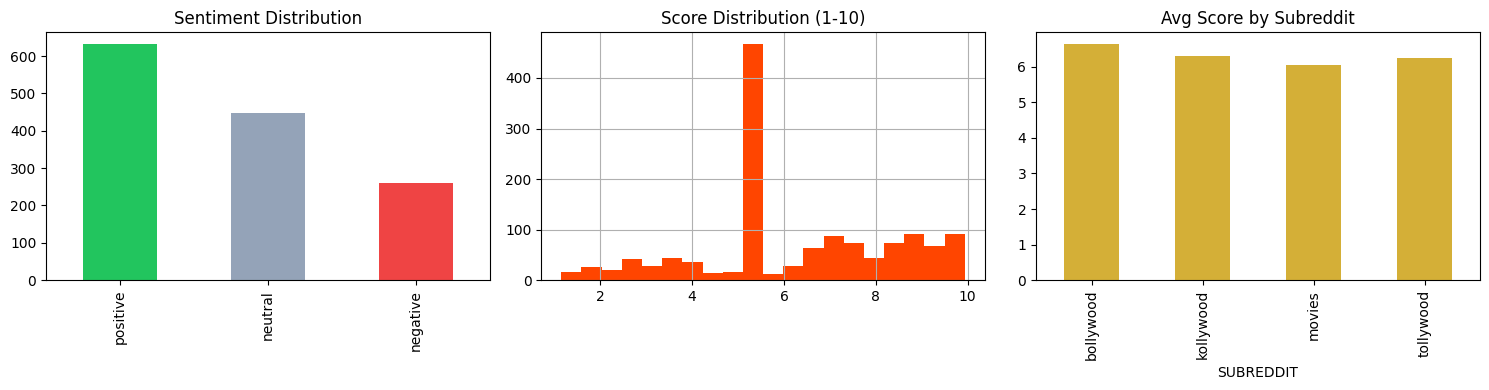

✅ Charts saved!


In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Sentiment distribution
df["SENTIMENT"].value_counts().plot(
    kind="bar", ax=axes[0], 
    color=["#22c55e", "#94a3b8", "#ef4444"]
)
axes[0].set_title("Sentiment Distribution")
axes[0].set_xlabel("")

# Score distribution
df["SCORE_10"].hist(ax=axes[1], bins=20, color="#FF4500")
axes[1].set_title("Score Distribution (1-10)")

# By subreddit
df.groupby("SUBREDDIT")["SCORE_10"].mean().plot(
    kind="bar", ax=axes[2], color="#d4af37"
)
axes[2].set_title("Avg Score by Subreddit")

plt.tight_layout()
plt.savefig("data/sentiment_charts.png")
plt.show()
print("✅ Charts saved!")

In [8]:
movie_scores = df.groupby("MOVIE_NAME").agg(
    REDDIT_SCORE    = ("SCORE_10", "mean"),
    TOTAL_COMMENTS  = ("COMMENT_TEXT", "count"),
    POSITIVE_PCT    = ("SENTIMENT", lambda x: round((x=="positive").mean()*100, 1)),
    NEGATIVE_PCT    = ("SENTIMENT", lambda x: round((x=="negative").mean()*100, 1)),
    NEUTRAL_PCT     = ("SENTIMENT", lambda x: round((x=="neutral").mean()*100, 1)),
).reset_index()

movie_scores["REDDIT_SCORE"] = movie_scores["REDDIT_SCORE"].round(2)

# Only keep movies with enough comments
movie_scores = movie_scores[movie_scores["TOTAL_COMMENTS"] >= 3]
movie_scores = movie_scores.sort_values("REDDIT_SCORE", ascending=False)

print(f"✅ Generated scores for {len(movie_scores)} movies")
movie_scores.head(10)

✅ Generated scores for 79 movies


,MOVIE_NAME,REDDIT_SCORE,TOTAL_COMMENTS,POSITIVE_PCT,NEGATIVE_PCT,NEUTRAL_PCT
4,Am I screwed as a physical media fan in the US?,8.54,4,100.0,0.0,0.0
17,"From scary to emotional, this scene quickly to...",8.04,4,100.0,0.0,0.0
40,Munna Re Release Trailer| Prabhas| Illeana| Va...,7.99,4,75.0,0.0,25.0
52,Revisited Veer-Zaara (2004) after years,7.95,6,100.0,0.0,0.0
41,Netflix’s ‘The 99’ers’ Adds Six To Cast,7.83,8,75.0,0.0,25.0
42,Oh Butterfly Trailer | Nivedhithaa Sathish &am...,7.82,4,100.0,0.0,0.0
81,Why Do We Rewatch Mediocre Bollywood Films But...,7.79,20,85.0,10.0,5.0
60,Still waiting for that upgrade...,7.78,8,75.0,0.0,25.0
35,Movie recommendations,7.66,24,75.0,0.0,25.0
72,"Two 'Naina's - both enacted by great actors, b...",7.50,20,70.0,10.0,20.0


In [11]:
 from snowflake.connector.pandas_tools import write_pandas

conn = snowflake.connector.connect(
    user="ATHULYA2303",
    password=os.getenv("SNOWFLAKE_PASSWORD"),
    account="gsc07824.us-east-1",
    warehouse="COMPUTE_WH",
    database="MOVIE_ANALYTICS",
    schema="ANALYTICS"
)

# Push comment scores
sentiment_df = df[[
    "MOVIE_NAME", "SUBREDDIT", "COMMENT_TEXT",
    "SENTIMENT", "SCORE_10", "COMPOUND", "COMMENT_TIMESTAMP"
]].copy()

write_pandas(conn, sentiment_df, "COMMENT_SCORES",
             database="MOVIE_ANALYTICS", schema="ANALYTICS")
print(f"✅ Pushed {len(sentiment_df)} scored comments to Snowflake")

# Push movie scores
write_pandas(conn, movie_scores, "MOVIE_RATINGS",
             database="MOVIE_ANALYTICS", schema="ANALYTICS",
             overwrite=True)
print(f"✅ Pushed {len(movie_scores)} movie scores to Snowflake")

conn.close()

✅ Pushed 1339 scored comments to Snowflake


/var/folders/9v/m7xlhp3j2cz1nmdxztqqdw200000gn/T/ipykernel_9682/2129349535.py:23: UserWarning: Pandas Dataframe has non-standard index of type <class 'pandas.core.indexes.base.Index'> which will not be written. Consider changing the index to pd.RangeIndex(start=0,...,step=1) or call reset_index() to keep index as column(s)
  write_pandas(conn, movie_scores, "MOVIE_RATINGS",


✅ Pushed 79 movie scores to Snowflake
